# <u>**Trabajo Práctico N°1 - Parte 2 "Procesos livianos (Threads)"**</u>

<u>Materia</u>: Programación Concurrente<br>
<u>Profesores</u>: Carnuccio Esteban, Hirschfeldt Dario, Palomo Maximo Facundo, Volker Mariano Leonardo<br>
<u>Grupo</u>: M4<br>
<u>Ciclo Lectivo</u>: 1er Cuatrimestre del 2026<br>
<u>Fecha</u>: 04/05/2026

## **a) Contador de caracteres<br>**

Crear un programa en C++, Python y JAVA que contabilice la cantidad de caracteres de un archivo de texto implementando threads.

El programa recibirá como parámetro el path al archivo de texto y un parámetro N que será la cantidad de threads a crear. Cada thread contabilizará la cantidad de caracteres de la/s línea/s que le corresponde/n analizar y almacenará el resultado en RP (Resultado Parcial), existiendo
N RP. Por último, el hilo principal sumará los resultados parciales generando un RT (Resultado Total) y lo imprimirá por pantalla, así como también el tiempo insumido por el procesamiento.

### **Contador de caracteres en C++<br>**

In [ ]:
%%writefile ejercicio1.cpp
#include <thread>
#include <iostream>
#include <fstream>
#include <vector>
#include <string>
#include <chrono>

using namespace std;
using namespace std::chrono;

void charsCounter(const vector<string>& lineas, unsigned int &rp, int inicio, int cantLineas)
{
    unsigned int acum = 0;

    for (int i = 0; i < cantLineas; i++) {
        acum += lineas[inicio+i].size();
    }

    rp = acum;
}

int main( int argc, char *argv[] )
{
    auto tiempoInicial = high_resolution_clock::now();

    if (argc < 3) {
        cerr << "El programa requiere 2 argumentos: Path del archivo de texto y cantidad de hilos a utilizar" << endl;
        return EXIT_FAILURE;
    }

    int cantHilos = stoi(argv[2]);
    vector<thread> hilos;
    string linea;
    vector<string> lineas;
    ifstream archivo(argv[1]);

    if (!archivo.is_open()) {
        cerr << "No se pudo abrir el archivo" << endl;
        return EXIT_FAILURE;
    }

    while (getline(archivo, linea)) {
        lineas.push_back(linea);
    }

    if (lineas.empty()) {
      cout << "Archivo vacío" << endl;
      return EXIT_SUCCESS;
    }

    cantHilos = min(cantHilos, (int)lineas.size());
    int cociente = lineas.size() / cantHilos;
    int resto = lineas.size() % cantHilos;
    vector<unsigned int> rps(cantHilos, 0);

    int lineasxThread = 0;
    int lineaInicial = 0;
    for (int i = 0; i < cantHilos; i++) {
      if (i < resto) {
        lineasxThread = cociente+1;
      }
      else {
        lineasxThread = cociente;
      }

      hilos.emplace_back(charsCounter, cref(lineas), ref(rps[i]), lineaInicial, lineasxThread);
      lineaInicial += lineasxThread;
    }

    for (auto &h : hilos) {
      h.join();
    }

    unsigned int rt = 0;
    for(int rp : rps) {
      rt += rp;
    }

    auto tiempoFinal = high_resolution_clock::now();
    duration<double> duracion = tiempoFinal - tiempoInicial;

    cout<<"Cantidad de caracteres del archivo: "<<rt<<endl;
    cout <<"Hilos usados: " << cantHilos << endl;
    cout<<"Tiempo insumido por el procesamiento: "<<duracion.count()*1000<<" ms"<<endl;

    return EXIT_SUCCESS;
}

Overwriting ejercicio1.cpp


In [ ]:
!g++ -o ejercicio1.bin ejercicio1.cpp

In [ ]:
%%writefile archivo.txt
linea 1 el procesamiento concurrente permite dividir tareas grandes en partes mas pequenas
linea 2 cada thread trabaja sobre un subconjunto de datos del problema original
linea 3 el uso de threads mejora el rendimiento en sistemas con multiples nucleos
linea 4 la division del trabajo debe ser lo mas equitativa posible entre los hilos
linea 5 cada hilo recibe un rango de lineas para procesar de forma independiente
linea 6 el hilo principal es responsable de coordinar la ejecucion de los threads
linea 7 los resultados parciales se almacenan en una estructura compartida
linea 8 no hay escritura concurrente sobre los datos de entrada
linea 9 por lo tanto no se requieren mecanismos de sincronizacion complejos
linea 10 el conteo de caracteres se realiza usando la funcion size de cada string
linea 11 cada linea del archivo es procesada exactamente una vez por un thread
linea 12 la suma parcial de cada thread se guarda en un vector de resultados
linea 13 luego el hilo principal combina todos los resultados parciales
linea 14 este enfoque es comun en problemas de data parallelism
linea 15 la eficiencia depende del numero de nucleos disponibles en el sistema
linea 16 en sistemas con pocos nucleos el speedup puede ser limitado
linea 17 en sistemas con muchos nucleos el rendimiento mejora significativamente
linea 18 la creacion de threads tiene un costo que debe ser considerado
linea 19 por eso no siempre mas threads significa mejor rendimiento
linea 20 el equilibrio entre trabajo y overhead es clave en concurrencia
linea 21 los algoritmos paralelos deben diseñarse cuidadosamente
linea 22 la lectura del archivo se realiza una sola vez en el hilo principal
linea 23 luego las lineas se almacenan en memoria para facilitar el acceso
linea 24 el acceso en memoria es mas rapido que el acceso a disco
linea 25 cada thread solo accede a su rango asignado de lineas
linea 26 esto evita condiciones de carrera en la lectura de datos
linea 27 el uso de referencias evita copias innecesarias de datos
linea 28 la funcion join asegura que todos los threads terminen antes de continuar
linea 29 el resultado final es la suma de todos los resultados parciales
linea 30 este tipo de problemas es ideal para practicar concurrencia
linea 31 la sincronizacion es minima porque no hay recursos compartidos mutables
linea 32 los datos son solo de lectura durante la ejecucion de los threads
linea 33 esto simplifica mucho el diseño del programa
linea 34 la escalabilidad depende de la arquitectura del procesador
linea 35 los sistemas modernos tienen soporte nativo para threads
linea 36 c plus plus ofrece la biblioteca thread para manejar concurrencia
linea 37 el uso correcto de threads puede mejorar significativamente el rendimiento
linea 38 es importante medir el tiempo de ejecucion para evaluar mejoras
linea 39 la clase chrono permite medir tiempos con precision
linea 40 los resultados pueden variar entre ejecuciones debido a la carga del sistema
linea 41 el planificador del sistema operativo asigna tiempo de CPU a cada thread
linea 42 en algunos casos los threads pueden ejecutarse en paralelo real
linea 43 en otros casos se ejecutan de forma intercalada
linea 44 el objetivo es aprovechar al maximo los recursos disponibles
linea 45 este ejercicio ayuda a entender conceptos de paralelismo
linea 46 y programacion concurrente en sistemas modernos
linea 47 cada thread realiza una tarea simple de suma de caracteres
linea 48 el resultado parcial es independiente de los otros threads
linea 49 esto elimina la necesidad de locks o mutex
linea 50 el programa finaliza cuando todos los threads han terminado
linea 51 el hilo principal recoge los resultados y los imprime
linea 52 este flujo es tipico en problemas de map reduce basico
linea 53 donde se divide trabajo y luego se combina resultado
linea 54 la eficiencia depende de la granularidad del trabajo
linea 55 trabajos muy pequeños pueden generar overhead excesivo
linea 56 trabajos muy grandes pueden limitar el paralelismo
linea 57 encontrar el balance correcto es parte del diseño del algoritmo
linea 58 este tipo de ejercicios es fundamental en sistemas operativos
linea 59 y programacion de alto rendimiento
linea 60 fin del archivo de prueba para concurrencia con threads en c++

Overwriting archivo.txt


In [ ]:
!./ejercicio1.bin archivo.txt 8

Cantidad de caracteres del archivo: 4197
Hilos usados: 8
Tiempo insumido por el procesamiento: 0.833655 ms


### **Contador de caracteres en Python<br>**

In [ ]:
%%writefile ejercicio2.py
import threading
import time
import sys

lineas = []

def charsCounter(rps, index, inicio, cantLineas):
    acum = 0
    for i in range(cantLineas):
      acum += len(lineas[inicio+i])

    rps[index] = acum

def main(param):
    tiempo_inicial = time.perf_counter()

    if len(param) < 3:
        print("El programa requiere 2 argumentos: Path del archivo de texto y cantidad de hilos a utilizar")
        sys.exit(1)

    cantHilos = int(param[2])
    hilos = []

    with open(param[1], "r") as archivo:
      for linea in archivo:
        lineas.append(linea.rstrip("\n"))

    if not lineas:
      print("Archivo vacío")
      sys.exit(0)

    cantHilos = min(cantHilos, len(lineas))
    cociente = len(lineas) // cantHilos
    resto = len(lineas) % cantHilos
    rps = [0] * cantHilos

    lineasxThread = 0
    lineaInicial = 0
    for i in range(cantHilos):
      if i < resto:
        lineasxThread = cociente+1
      else:
        lineasxThread = cociente

      hilos.append(threading.Thread(target=charsCounter, args=(rps, i, lineaInicial, lineasxThread)))
      lineaInicial += lineasxThread

    for hilo in hilos:
      hilo.start()

    for hilo in hilos:
      hilo.join()

    rt = sum(rps)
    tiempo_final = time.perf_counter()

    print("Cantidad de caracteres del archivo: ", rt)
    print("Hilos usados: ", cantHilos)
    print("Tiempo insumido por el procesamiento:", (tiempo_final - tiempo_inicial)*1000, "ms")

if __name__ == '__main__':
    main(sys.argv)

Overwriting ejercicio2.py


In [ ]:
! python ejercicio2.py archivo.txt 8

Cantidad de caracteres del archivo:  4193
Hilos usados:  8
Tiempo insumido por el procesamiento: 1.6007369995350018 ms


### **Contador de caracteres en Java<br>**

In [ ]:
%%writefile Ejercicio3.java
import java.io.*;
import java.util.ArrayList;

public class Ejercicio3
{
    static ArrayList<String> lineas = new ArrayList<>();
    static int[] parciales;

    public static class CharsCounter extends Thread
    {
        private int index;
        private int cantLineas;
        private int inicio;

        public CharsCounter(int i, int cantL, int ini)
        {
            index = i;
            cantLineas = cantL;
            inicio = ini;
        }

        public void run()
        {
            int acum = 0;

            for (int i = 0; i < this.cantLineas; i++) {
              acum += lineas.get(this.inicio + i).length();
            }

            parciales[this.index] = acum;
        }
    }

    public static void main(String[] args) throws InterruptedException
    {
        long inicio = System.currentTimeMillis();

        if (args.length < 2) {
          System.out.println("El programa requiere 2 argumentos: Path del archivo de texto y cantidad de hilos a utilizar");
          System.exit(1);
        }

        int cantHilos = Integer.parseInt(args[1]);
        CharsCounter[] hilos;

        try (BufferedReader br = new BufferedReader(new FileReader(args[0]))) {
          String linea;

          while ((linea = br.readLine()) != null) {
            lineas.add(linea);
          }
        } catch (IOException e) {
            System.err.println("Error leyendo el archivo: " + e.getMessage());
            System.exit(1);
        }

        if (lineas.isEmpty()){
          System.out.println("Archivo vacío");
          System.exit(0);
        }

        cantHilos = Math.min(cantHilos, lineas.size());
        int cociente = lineas.size() / cantHilos;
        int resto = lineas.size() % cantHilos;
        parciales = new int[cantHilos];
        hilos = new CharsCounter[cantHilos];

        int lineasxThread = 0;
        int lineaInicial = 0;

        for (int i = 0; i < cantHilos; i++) {
          if (i < resto){
            lineasxThread = cociente+1;
          }
          else {
            lineasxThread = cociente;
          }

          hilos[i] = new CharsCounter(i, lineasxThread, lineaInicial);
          lineaInicial += lineasxThread;
        }

        for (CharsCounter hilo : hilos) {
          hilo.start();
        }

        for (CharsCounter hilo : hilos) {
          hilo.join();
        }

        int resultado = 0;

        for (int parcial : parciales) {
          resultado += parcial;
        }

        long fin = System.currentTimeMillis();

        System.out.println("Cantidad de caracteres del archivo: " + resultado);
        System.out.println("Hilos usados: " + cantHilos);
        System.out.println("Tiempo insumido por el procesamiento: " + (fin - inicio) + " ms");
    }
}

Overwriting Ejercicio3.java


In [ ]:
!javac Ejercicio3.java

In [ ]:
!java Ejercicio3 archivo.txt 8

Cantidad de caracteres del archivo: 4193
Hilos usados: 8
Tiempo insumido por el procesamiento: 4 ms


## **b) Toma de tiempos**

Realizar una toma de tiempos (milisegundos) con los programas del punto anterior
generando una tabla comparativa entre lenguajes y emitir conclusiones.

N,Tiempo C++,Tiempo Python,Tiempo Java
1,0.38,0.62,3.00
30,2.51,4.20,8.00
60,3.41,9.62,16.00


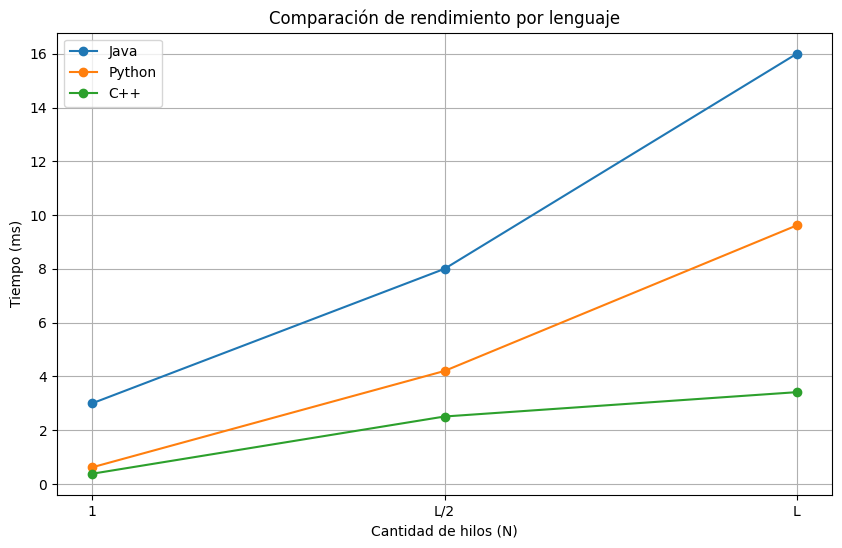

In [ ]:
import subprocess
import re
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def run_cmd(cmd):
    result = subprocess.run(cmd, capture_output=True, text=True)
    return result.stdout


def extraer_tiempo(texto):
    return float(re.search(r"([0-9.]+)\s*ms", texto).group(1))

hilos = [1, 30, 60]

resultados = {
    "N": [],
    "Tiempo C++": [],
    "Tiempo Python": [],
    "Tiempo Java": []
}

for n in hilos:
    out_cpp = run_cmd(["./ejercicio1.bin", "archivo.txt", str(n)])
    t_cpp = extraer_tiempo(out_cpp)

    out_py = run_cmd(["python", "ejercicio2.py", "archivo.txt", str(n)])
    t_py = extraer_tiempo(out_py)

    out_java = run_cmd(["java", "Ejercicio3", "archivo.txt", str(n)])
    t_java = extraer_tiempo(out_java)

    resultados["N"].append(str(n))
    resultados["Tiempo C++"].append(t_cpp)
    resultados["Tiempo Python"].append(t_py)
    resultados["Tiempo Java"].append(t_java)


df = pd.DataFrame(resultados)
styled = (
    df.style
    .hide(axis="index")
    .format({
        "Tiempo C++": "{:.2f}",
        "Tiempo Python": "{:.2f}",
        "Tiempo Java": "{:.2f}"
    })
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size", "22px"),
                   ("font-weight", "bold"),
                   ("text-align", "center")]},

        {"selector": "th",
         "props": [("font-size", "18px"),
                   ("text-align", "center")]},

        {"selector": "td",
         "props": [("text-align", "center"),
                   ("font-size", "16px")]}
    ])
    .background_gradient(cmap="YlOrRd", subset=["Tiempo C++", "Tiempo Python", "Tiempo Java"])
)
display(styled)


x = range(len(df["N"]))

plt.figure(figsize=(10,6))

plt.plot(x, df["Tiempo Java"], marker="o", label="Java")
plt.plot(x, df["Tiempo Python"], marker="o", label="Python")
plt.plot(x, df["Tiempo C++"], marker="o", label="C++")

plt.xticks(x, ["1", "L/2", "L"])
plt.xlabel("Cantidad de hilos (N)")
plt.ylabel("Tiempo (ms)")
plt.title("Comparación de rendimiento por lenguaje")
plt.grid(True)
plt.legend()

plt.show()

**En conclusión: Se puede ver en la tabla y el gráfico como el tiempo que le lleva a los tres lenguajes ejecutar el mismo programa aumenta a medida que crece la cantidad de hilos que utilizamos. Esto puede deberse a varios factores como son el overhead de crear y gestionar múltiples hilos, o generar más hilos que cantidad real de núcleos, lo que hace que haya más competencia por el procesador, además del constante context switching que hay que realizar. Todo esto nos demuestra que no siempre muchos hilos significa necesariamente más velocidad. Además también podemos notar como hay lenguajes que por su cercanía al hardware y menos capas intermedias son más eficientes y veloces, como es el caso de C++, que en los 3 casos es el más rápido, y su curva de crecimiento es menos pronunciada que la de Python y Java. Esto claramente se debe a que C++ se compila directo a código máquina sin intermediarios (intérpretes o máquinas virtuales), además de que los threads que utiliza se mapean directamente a los pthreads del sistema operativo. Luego le sigue Python, que demora más debido a que pasa por el intérprete en tiempo de ejecución, por lo que lógicamente al agregarle una capa extra, va a demandar más tiempo. Sin mencionar que Python cuenta con GIL (Global Interpreter Lock), lo que genera que solo un hilo se ejecute a la vez en procesos CPU-bound (que es nuestro caso), tal vez si cada hilo leyera del archivo podría demorar un poco menos debido a que son procesos I/O-bound, pero el simple hecho de pasar por el GIL constantemente genera un mayor overhead y por eso termina siendo más lento que C++. Por último tenemos el caso de JAVA, que es mucho más lento que C++ y Python, debido a que cuenta con el Garbage Collector y la JVM corriendo en tiempo de ejecución, lo que agrega más overhead, sumado por suepuesto a los factores comúnes que mencionamos al principio como el context switching. Todo esto sumado genera que JAVA sea más lento en comparación con C++ y Python.**